### Langgraph: A Modern Framework for building multi node agents with each node having unique functionality and specific works subdivided.

### Imports

In [164]:
import json
import random
from pydantic import BaseModel
from typing import Optional, List, Dict, Any,TypedDict,Annotated
import operator
import os
from dotenv import load_dotenv

In [165]:
from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.messages import HumanMessage,SystemMessage
from langchain_ollama import ChatOllama
from langchain.tools import tool
from tavily import TavilyClient
from tavily.exceptions import BadRequestError

### Trying tavily client API for search

In [ ]:
load_dotenv()
client = TavilyClient(api_key=os.getenv('TAVILY_API_KEY'))
tavily_results = client.search("what do Jane Street does ?find out their top news.",include_answers=True,search_depth='advanced')

### Cleaning the api response and using what needed before feeding back to model

In [169]:
print(tavily_results.get('answer'))
# tavily does not respond with answers but 
# it is responding with some results
print(tavily_results.get("results"))

None
[{'url': 'https://www.janestreet.com/the-latest', 'title': 'The Latest :: Jane Street', 'content': "For information regarding our cookie practices, see Jane Street’s [Ad and Cookie Policy](https://www.janestreet.com/ad-cookie-policy). [![Image 1: Jane Street logo](https://www.janestreet.com/assets/logo_horizontal-16929188a56384c8e77bea91967c4553146ed7293f60a8f4f2ab6a06187881ce.svg)](https://www.janestreet.com/). *   [WHO WE ARE](https://www.janestreet.com/who-we-are/). *   [JOIN JANE STREET](https://www.janestreet.com/join-jane-street/overview/). *   [DEPARTMENTS](https://www.janestreet.com/join-jane-street/departments/). *   [OPEN ROLES](https://www.janestreet.com/join-jane-street/open-roles/). *   [PROGRAMS AND EVENTS](https://www.janestreet.com/join-jane-street/programs-and-events/). *   [INTERNSHIPS](https://www.janestreet.com/join-jane-street/internships/). *   [INTERVIEWING](https://www.janestreet.com/join-jane-street/interviewing/). *   [Who We Are](https://www.janestreet.c

### Generating a dataframe with top 3 Sources with Content

In [171]:
results = tavily_results.get('results',[])
import pandas as pd
sources = []
content= []
for result in results:
  for k,v in result.items():
    if k=="url":
      sources.append(v)
    elif k =="content":
      content.append(v)

search_result = pd.DataFrame({"source":sources, "content":content})

search_result

,source,content
0,https://www.janestreet.com/the-latest,For information regarding our cookie practices...
1,https://www.janestreet.com/who-we-are,We were founded by a small group of traders an...
2,https://www.youtube.com/watch?v=6LkMI6uvqZY&vl=en,How a Secretive Trading Empire Is Taking Over ...
3,https://www.janestreet.com/join-jane-street/ov...,### We look for smart people with curious mind...
4,https://www.reddit.com/r/quant/comments/1an8dk...,Skip to main contentHow exactly does Jane Stre...


### System_instruction & Human Prompt

In [172]:
system_instruction = """You are an expert research assistant and note-taker.
  Your job is to read raw web content and distill it into 
  clean, structured study notes for a learner.
  
  Your ONLY output must be valid JSON — no prose, no markdown 
  fences, no explanation outside the JSON.
  
  Respond with this exact schema:
  {{
    "subtopic": string
    "summary": string,
    "key_concepts": [string],
    "important_facts": [string],
    "study_tips": [string],
    "sources_used": [string]
  }}
  
  
  Rules:
  - summary must be 3-5 sentences maximum
  - key_concepts must have 3-5 items
  - important_facts must have 3-5 items  
  - study_tips must have 2-3 items
  - Never invent facts not present in the provided content
  - If content is insufficient, say so in summary field"""

human_prompt = """Subtopic: {subtopic}

  Raw content:
  {tavily_results}

  Level: {level} 

  Then output ONLY the JSON notes — no reasoning in response."""  

#### defined a langgraph state

In [173]:
class State(TypedDict):
  subtopic : str
  level: str
  tavily_results: Optional[dict] 
  notes : Optional[dict] 
  error : Annotated[list[str],operator.add]

### Inititalize the llm

In [174]:
llm = ChatOllama(model='mistral:latest',temperature=0.3)

### tavily search as NODE

In [175]:
# node - 1
def tavily_search(state:State):
  try:
    search_output = client.search(state['subtopic'])

    contents = []
    sources = []
    
    results = search_output.get('results',[])
    for result in results[:4]:
      contents.append(result['content'])
      sources.append(result['url'])
    tavily_results = {"contents":contents,"sources":sources}

    return {"tavily_results":tavily_results }
  except BadRequestError as e:
    print(e)
    return {"error":[e]}

### Researcher Agent Node to Summarize tavily output

In [176]:
# node - 2
def researcher_agent(state:State):
  subtopic = state['subtopic']
  tavily_results = state['tavily_results']
  
  system_prompt = SystemMessage(content=system_instruction)

  final_prompt = ChatPromptTemplate.from_messages([
    system_prompt,
    ('human',human_prompt)
  ])

  parser = JsonOutputParser()

  chain = final_prompt | llm | parser
  node_input = {"subtopic":subtopic,"tavily_results":tavily_results,"level":"medium"}
  response = chain.invoke(node_input)

  return {"notes":response}

### Building The Graph with State

In [177]:
graph_builder = StateGraph(State)

graph_builder.add_node("tavily_search",tavily_search)
graph_builder.add_node("researcher_agent",researcher_agent)

graph_builder.add_edge(START,"tavily_search")
graph_builder.add_edge("tavily_search",'researcher_agent')
graph_builder.add_edge("researcher_agent",END)

graph = graph_builder.compile()

### Graph image using display

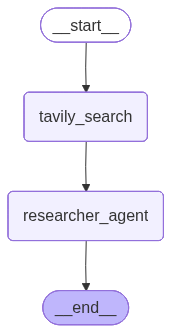

In [178]:
from IPython.display import Image, display

def display_graph(graph):
  return display(Image(graph.get_graph().draw_mermaid_png()))

display_graph(graph)

### invoking the graph with state.subtopic

In [180]:
response = graph.invoke({"subtopic":"python decorators","level":"medium","error":[]})

#### the final Response which has search outputs and llm generated response all as json formatting

In [186]:
response_json = response.get('tavily_results')
notes = response.get('notes')


from rich.console import Console

console = Console()
console.print(response.get('notes'))


{
    'subtopic': 'Python Decorators',
    'summary': 'Python decorators allow modifying or extending function behavior without changing their code. They 
are higher-order functions that can take a function, modify it, and return a new one with extended or altered 
behavior. Class decorators are used to modify class behavior. Decorators provide a simple way to implement 
higher-order functions in Python.',
    'key_concepts': ['higher-order functions', 'decorator as a function', 'class decorators'],
    'important_facts': [
        'Decorators wrap a function with another function',
        'They can add functionality before and after a function call',
        'The `print()` function is an example of a function returning a value based on arguments'
    ],
    'study_tips': [
        'Understand the concept of higher-order functions',
        'Practice writing decorators for simple functions',
        'Explore class decorators to modify class behavior'
    ],
    'sources_used': [
        'https://realpython.com/primer-on-python-decorators',
        'https://www.geeksforgeeks.org/python/decorators-in-python',
        'https://medium.com/codex/decorators-in-python-a-brief-29ea8966b9f2'
    ]
}

In [189]:
notes = response.get('notes',{})
with open("data-7.json",'w',encoding='utf-8') as f:
  f.write(json.dumps(notes,indent=4))
  print("data saved as json")

data saved as json
